In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
df=pd.read_csv("drug200.csv")

In [95]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [96]:
df.shape

(200, 6)

In [97]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [99]:
df[df.duplicated(df)]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug


In [100]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

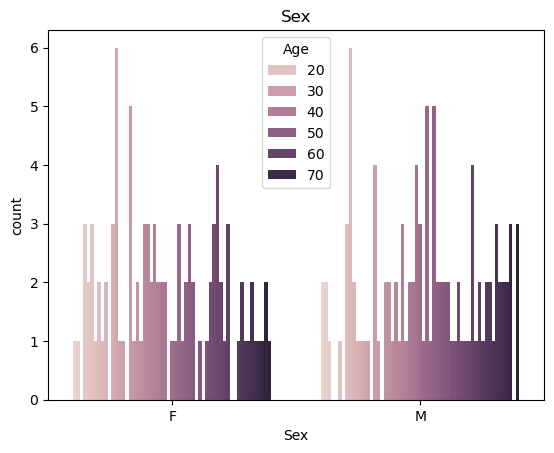

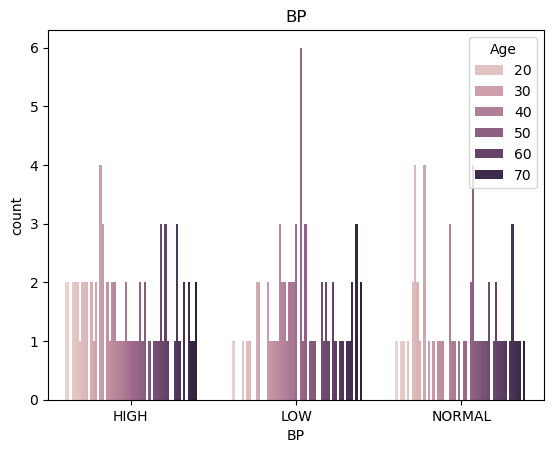

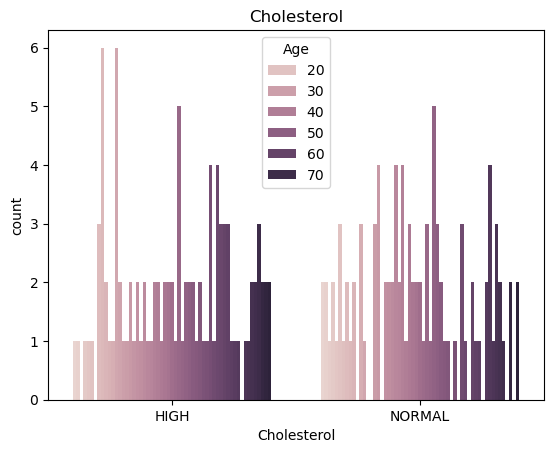

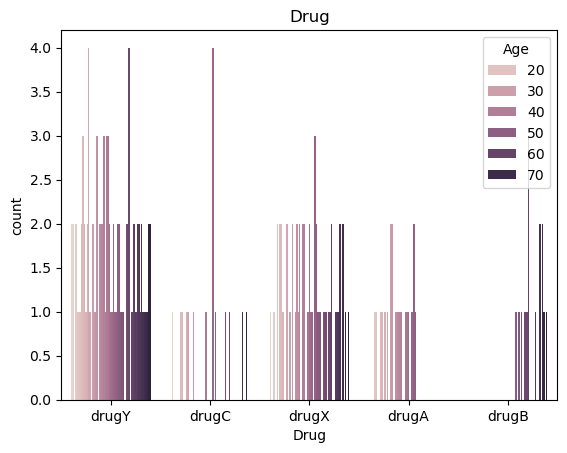

In [101]:
categoric_list=["Sex","BP","Cholesterol","Drug"]

for i in categoric_list:
    sns.countplot(x=df[i],hue=df["Age"])
    plt.title(i)
    plt.show()

<Axes: xlabel='Drug', ylabel='count'>

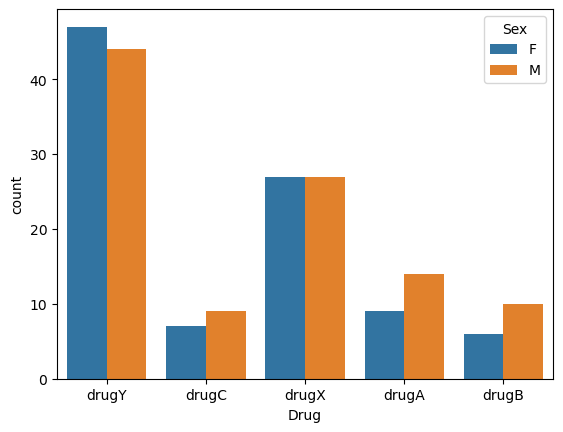

In [102]:
sns.countplot(x=df["Drug"],hue=df["Sex"])

In [103]:
#Dependent Independent
X=df.drop("Drug",axis=1)
y=df["Drug"]

In [104]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=15)

In [105]:
X_train

,Age,Sex,BP,Cholesterol,Na_to_K
97,56,F,HIGH,HIGH,25.395
20,57,M,LOW,NORMAL,19.128
169,20,F,HIGH,HIGH,11.262
137,35,F,HIGH,HIGH,12.894
181,59,F,NORMAL,HIGH,13.884
...,...,...,...,...,...
156,31,M,HIGH,NORMAL,11.227
128,47,M,LOW,NORMAL,33.542
119,61,F,HIGH,HIGH,25.475
133,24,M,NORMAL,HIGH,25.786


In [106]:
#encode
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
X_train_transformed=X_train
X_test_transformed=X_test
X_train_transformed=pd.get_dummies(X_train_transformed,columns=["Sex"],drop_first=True,dtype=int)
X_test_transformed=pd.get_dummies(X_test_transformed,columns=["Sex"],drop_first=True,dtype=int)
X_train_transformed

,Age,BP,Cholesterol,Na_to_K,Sex_M
97,56,HIGH,HIGH,25.395,0
20,57,LOW,NORMAL,19.128,1
169,20,HIGH,HIGH,11.262,0
137,35,HIGH,HIGH,12.894,0
181,59,NORMAL,HIGH,13.884,0
...,...,...,...,...,...
156,31,HIGH,NORMAL,11.227,1
128,47,LOW,NORMAL,33.542,1
119,61,HIGH,HIGH,25.475,0
133,24,NORMAL,HIGH,25.786,1


In [107]:
#Encode 

categorical=["BP","Cholesterol"]
order_encode=OrdinalEncoder(categories=[
    ["HIGH","NORMAL","LOW"],#BP
    ["HIGH","NORMAL"]#Cholesterol

])
preprocessor=ColumnTransformer(transformers=[
    ("encodetransform",order_encode,categorical)],remainder="passthrough")
X_train_transformed=preprocessor.fit_transform(X_train_transformed)
X_test_transformed=preprocessor.transform(X_test_transformed)
    

In [108]:
X_train_transformed
    

array([[ 0.   ,  0.   , 56.   , 25.395,  0.   ],
       [ 2.   ,  1.   , 57.   , 19.128,  1.   ],
       [ 0.   ,  0.   , 20.   , 11.262,  0.   ],
       [ 0.   ,  0.   , 35.   , 12.894,  0.   ],
       [ 1.   ,  0.   , 59.   , 13.884,  0.   ],
       [ 0.   ,  1.   , 34.   , 19.199,  0.   ],
       [ 1.   ,  0.   , 23.   , 31.686,  1.   ],
       [ 0.   ,  1.   , 36.   , 15.49 ,  0.   ],
       [ 1.   ,  0.   , 28.   ,  7.798,  0.   ],
       [ 0.   ,  0.   , 34.   , 18.703,  1.   ],
       [ 1.   ,  0.   , 22.   ,  8.607,  0.   ],
       [ 2.   ,  0.   , 74.   , 20.942,  0.   ],
       [ 1.   ,  0.   , 54.   , 24.658,  1.   ],
       [ 0.   ,  0.   , 23.   , 25.355,  0.   ],
       [ 2.   ,  1.   , 72.   , 14.642,  0.   ],
       [ 0.   ,  1.   , 72.   ,  9.677,  1.   ],
       [ 1.   ,  1.   , 49.   ,  9.381,  0.   ],
       [ 1.   ,  1.   , 50.   , 17.211,  0.   ],
       [ 1.   ,  0.   , 67.   , 15.891,  0.   ],
       [ 0.   ,  1.   , 31.   , 11.871,  1.   ],
       [ 2.   ,  1. 

In [112]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=15)
tree.fit(X_train_transformed,y_train)

DecisionTreeClassifier(random_state=15)

In [113]:
#Metrics
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
y_pred=tree.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9833333333333333
              precision    recall  f1-score   support

       drugA       0.89      1.00      0.94         8
       drugB       1.00      0.83      0.91         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        26

    accuracy                           0.98        60
   macro avg       0.98      0.97      0.97        60
weighted avg       0.99      0.98      0.98        60

[[ 8  0  0  0  0]
 [ 1  5  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 16  0]
 [ 0  0  0  0 26]]


In [116]:
#hyperparameters tuning
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cv=StratifiedKFold()
params={"criterion":["gini", "entropy", "log_loss"],
        "splitter":["best","random"],
        "max_depth":[1,2,3,4,5,10,16,None],
        "max_features":["sqrt", "log2",None]}
grid_tree=GridSearchCV(estimator=tree,cv=cv,param_grid=params,n_jobs=-1)
grid_tree.fit(X_train_transformed,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(random_state=15), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 16, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']})

In [119]:
y_pred_tree=grid_tree.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_tree))
print(classification_report(y_test,y_pred_tree))
print(confusion_matrix(y_test,y_pred_tree))

0.9833333333333333
              precision    recall  f1-score   support

       drugA       0.89      1.00      0.94         8
       drugB       1.00      0.83      0.91         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        26

    accuracy                           0.98        60
   macro avg       0.98      0.97      0.97        60
weighted avg       0.99      0.98      0.98        60

[[ 8  0  0  0  0]
 [ 1  5  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 16  0]
 [ 0  0  0  0 26]]


In [120]:
grid_tree.best_params_

{'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'splitter': 'best'}

In [122]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()
logistic.fit(X_train_transformed,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [123]:
y_pred_logistic=logistic.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_logistic))
print(classification_report(y_test,y_pred_logistic))
print(confusion_matrix(y_test,y_pred_logistic))

0.8333333333333334
              precision    recall  f1-score   support

       drugA       0.75      0.75      0.75         8
       drugB       0.83      0.83      0.83         6
       drugC       1.00      0.75      0.86         4
       drugX       1.00      0.69      0.81        16
       drugY       0.78      0.96      0.86        26

    accuracy                           0.83        60
   macro avg       0.87      0.80      0.82        60
weighted avg       0.86      0.83      0.83        60

[[ 6  0  0  0  2]
 [ 1  5  0  0  0]
 [ 0  0  3  0  1]
 [ 0  1  0 11  4]
 [ 1  0  0  0 25]]


In [125]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_transformed,y_train)

KNeighborsClassifier()

In [127]:
y_pred_knn=knn.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.65
              precision    recall  f1-score   support

       drugA       0.36      0.50      0.42         8
       drugB       0.50      0.33      0.40         6
       drugC       0.25      0.25      0.25         4
       drugX       0.53      0.50      0.52        16
       drugY       0.92      0.92      0.92        26

    accuracy                           0.65        60
   macro avg       0.51      0.50      0.50        60
weighted avg       0.66      0.65      0.65        60

[[ 4  0  1  3  0]
 [ 0  2  1  3  0]
 [ 1  0  1  1  1]
 [ 4  2  1  8  1]
 [ 2  0  0  0 24]]


In [128]:
#hyperparameters KNN
params_knn={
    "n_neighbors":[1,2,3,4,5,6,16],
    "weights":["uniform","distance"],
    "algorithm":["auto","ball_tree","kd_tree","brute"]}
grid_knn=GridSearchCV(estimator=knn,param_grid=params_knn,cv=cv,n_jobs=-1)
grid_knn.fit(X_train_transformed,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 16],
                         'weights': ['uniform', 'distance']})

In [129]:
y_pred_knn_grid=grid_knn.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_knn_grid))
print(classification_report(y_test,y_pred_knn_grid))
print(confusion_matrix(y_test,y_pred_knn_grid))

0.7
              precision    recall  f1-score   support

       drugA       0.57      0.50      0.53         8
       drugB       0.67      0.33      0.44         6
       drugC       0.50      0.25      0.33         4
       drugX       0.52      0.69      0.59        16
       drugY       0.89      0.92      0.91        26

    accuracy                           0.70        60
   macro avg       0.63      0.54      0.56        60
weighted avg       0.70      0.70      0.69        60

[[ 4  0  1  3  0]
 [ 0  2  0  4  0]
 [ 0  0  1  2  1]
 [ 2  1  0 11  2]
 [ 1  0  0  1 24]]


In [130]:
#SVC
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train_transformed,y_train)

SVC()

In [131]:
y_pred_svc=svc.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))
print(confusion_matrix(y_test,y_pred_svc))

0.65
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         8
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.45      0.94      0.61        16
       drugY       0.89      0.92      0.91        26

    accuracy                           0.65        60
   macro avg       0.27      0.37      0.30        60
weighted avg       0.51      0.65      0.56        60

[[ 0  0  0  7  1]
 [ 0  0  0  6  0]
 [ 0  0  0  3  1]
 [ 0  0  0 15  1]
 [ 0  0  0  2 24]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [134]:
#hyperparameters
params_svc={
    "C":[0.01,0.1,1,10,50,100,1000],
    "kernel":["linear","poly","rbf","sigmoid"],
    "gamma":["scale","auto"]
}
grid_svc=GridSearchCV(estimator=svc,param_grid=params_svc,cv=cv,n_jobs=-1)

In [135]:
y_pred_svc_grid=svc.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred_svc_grid))
print(classification_report(y_test,y_pred_svc_grid))
print(confusion_matrix(y_test,y_pred_svc_grid))

0.65
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         8
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.45      0.94      0.61        16
       drugY       0.89      0.92      0.91        26

    accuracy                           0.65        60
   macro avg       0.27      0.37      0.30        60
weighted avg       0.51      0.65      0.56        60

[[ 0  0  0  7  1]
 [ 0  0  0  6  0]
 [ 0  0  0  3  1]
 [ 0  0  0 15  1]
 [ 0  0  0  2 24]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
